1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Divide the dataset into 2 training and test sets
4. Use Pipeline
    4. a. Use scaler and dimensional reduction (if it is necessary).
    4. b. Use suitable Naive Bayes for this problem.
5. Perform model on training set and test set using gridsearch CV
6. Measure performance of the model.
7. Which metric is your main metric for this problem and why? What are your scaler, dimensional reduction and naive bayes model as well as their params? (<= 200 words, also input your opinion or conclusion here)


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable. The final error based on my train and test set is low enough.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

A Travel Company Is Offering Travel Insurance Packages To Their Customers. The new insurance plan also covers Covid-19. The Company Claims To Know Which Customers Are Interested To Buy It Based On The Company's Database History.

* Age - Age Of The Customer
* Employment Type - The Sector In Which Customer Is Employed
GraduateOrNot - Whether The Customer Is College Graduate Or Not
* AnnualIncome - The Yearly Income Of The Customer In Indian Rupees
* FamilyMembers - Number Of Members In Customer's Family
* ChronicDisease - Whether The Customer Suffers From Any Major Disease Or Conditions Like Diabetes/High BP or Asthama,etc.
* FrequentFlyer - Derived Data Based On Customer's History Of Booking Air Tickets On Atleast 4 Different Instances In The Last 2 Years (2017-2019).
* EverTravelledAbroad - Has The Customer Ever Travelled To A Foreign Country
* TravelInsurance - Did The Customer Buy Travel Insurance Package During Introductory Offering Held In The Year 2019.

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd
PATH = "D:/NMMH/(GauNaiveBayes) travel-insurance-prediction/TravelInsurancePrediction.csv"

df = pd.read_csv(PATH)
df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           1987 non-null   int64 
 1   Age                  1987 non-null   int64 
 2   Employment Type      1987 non-null   object
 3   GraduateOrNot        1987 non-null   object
 4   AnnualIncome         1987 non-null   int64 
 5   FamilyMembers        1987 non-null   int64 
 6   ChronicDiseases      1987 non-null   int64 
 7   FrequentFlyer        1987 non-null   object
 8   EverTravelledAbroad  1987 non-null   object
 9   TravelInsurance      1987 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.4+ KB


## Data Analysis

In [4]:
df.describe()

,Unnamed: 0,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1987.000000,1.987000e+03,1987.000000,1987.000000,1987.000000
mean,993.000000,29.650226,9.327630e+05,4.752894,0.277806,0.357323
std,573.741812,2.913308,3.768557e+05,1.609650,0.448030,0.479332
min,0.000000,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,496.500000,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,993.000000,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,1489.500000,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,1986.000000,35.000000,1.800000e+06,9.000000,1.000000,1.000000


In [5]:
print("Continous Columns")
continous_columns = df[['Age', 'AnnualIncome']]
print(continous_columns.head())

print("Category Columns")
category_columns = df[['Employment Type', 'GraduateOrNot', 'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer', 'EverTravelledAbroad', 'TravelInsurance']]
print(category_columns.head())

Continous Columns
   Age  AnnualIncome
0   31        400000
1   31       1250000
2   34        500000
3   28        700000
4   28        700000
Category Columns
                Employment Type GraduateOrNot  FamilyMembers  ChronicDiseases  \
0             Government Sector           Yes              6                1   
1  Private Sector/Self Employed           Yes              7                0   
2  Private Sector/Self Employed           Yes              4                1   
3  Private Sector/Self Employed           Yes              3                1   
4  Private Sector/Self Employed           Yes              8                1   

  FrequentFlyer EverTravelledAbroad  TravelInsurance  
0            No                  No                0  
1            No                  No                0  
2            No                  No                1  
3            No                  No                0  
4           Yes                  No                0  


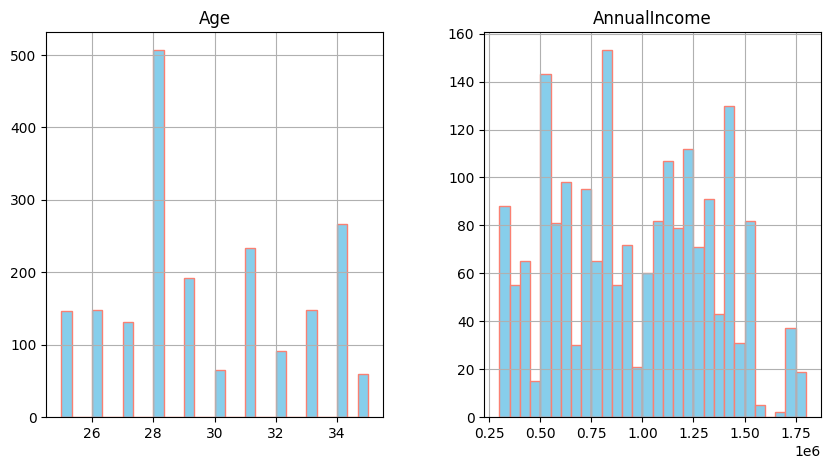

In [6]:
continous_columns.hist(figsize=(10,5), color="skyblue", edgecolor="salmon", bins=30)
plt.show()

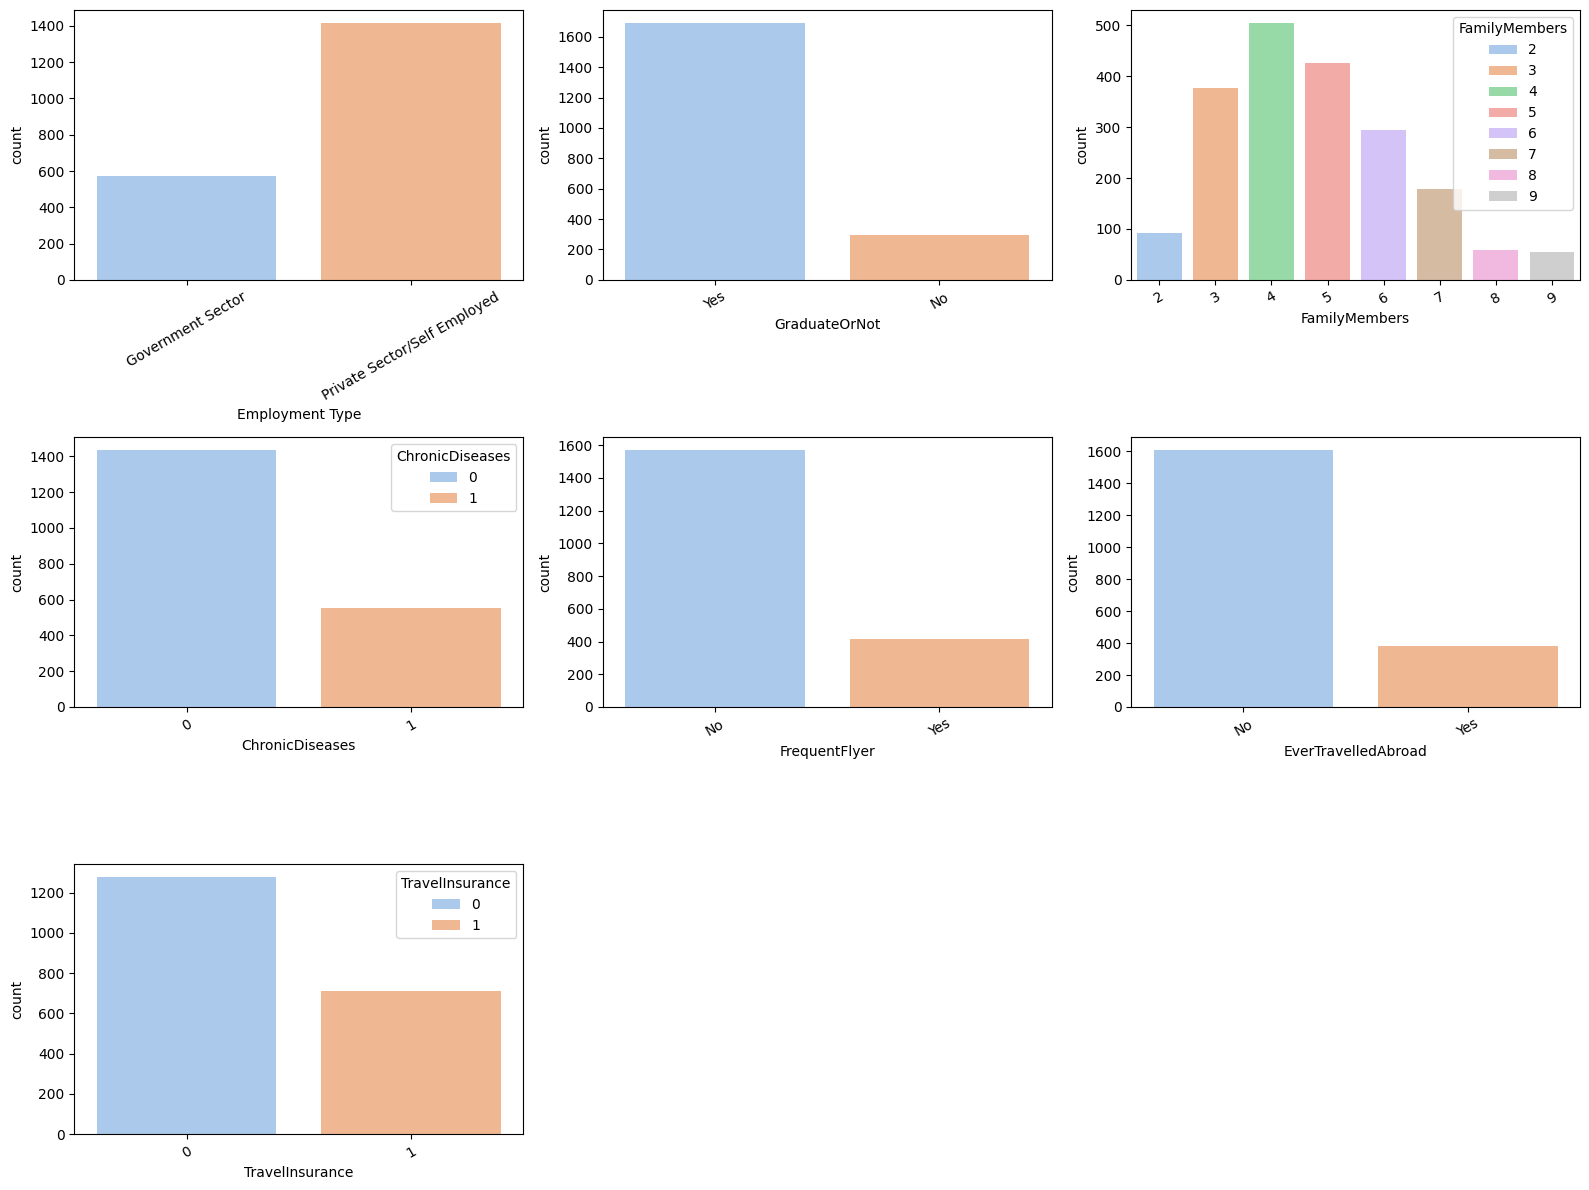

In [7]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(category_columns.columns):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=category_columns, x=col, hue=col, palette="pastel")
    plt.xlabel(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

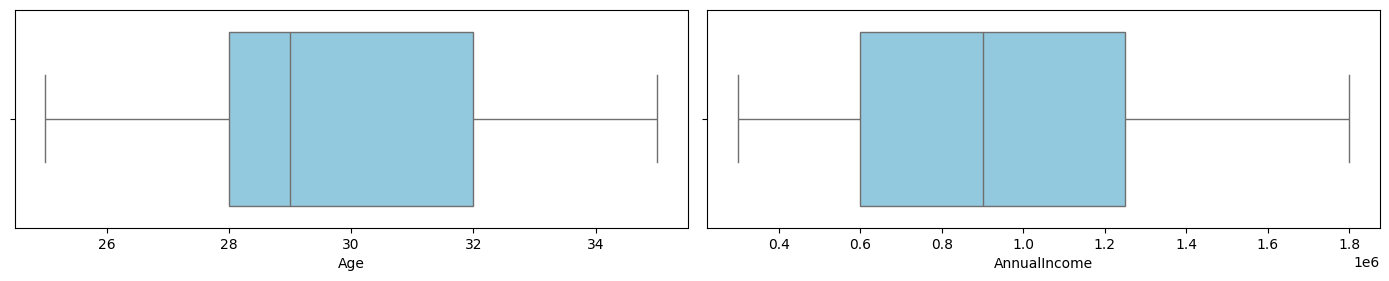

In [8]:
plt.figure(figsize=(14, 8))

for i, col in enumerate(continous_columns.columns):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=continous_columns[col], color="skyblue")

plt.tight_layout()
plt.show()

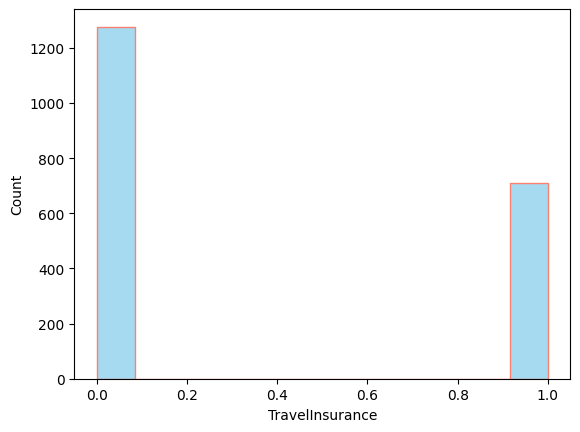

In [9]:
sns.histplot(x="TravelInsurance", data=df, color="skyblue", edgecolor="salmon")
plt.show()

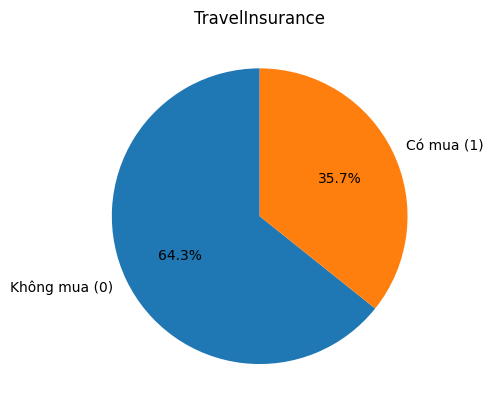

In [10]:
value_counts = df['TravelInsurance'].value_counts(normalize=True) * 100
plt.pie(value_counts, labels=['Không mua (0)', 'Có mua (1)'], autopct='%1.1f%%', startangle=90)
plt.title('TravelInsurance')
plt.show()

In [11]:
df.isnull().sum()

Unnamed: 0             0
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

## Preprocessing

In [12]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    df = df.drop(df.columns[[0]], axis=1)
    return df

In [13]:
df_ = preprocessing_data(df.copy())
df_.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


## Feature Engineering

In [14]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    df['Employment Type'] = LabelEncoder().fit_transform(df['Employment Type'])
    df['GraduateOrNot'] = LabelEncoder().fit_transform(df['GraduateOrNot'])
    df['FrequentFlyer'] = LabelEncoder().fit_transform(df['FrequentFlyer'])
    df['EverTravelledAbroad'] = LabelEncoder().fit_transform(df['EverTravelledAbroad'])
    
    return df

In [15]:
df_ = apply_feature_engineering(df_)
df_.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,0,1,400000,6,1,0,0,0
1,31,1,1,1250000,7,0,0,0,0
2,34,1,1,500000,4,1,0,0,1
3,28,1,1,700000,3,1,0,0,0
4,28,1,1,700000,8,1,1,0,0


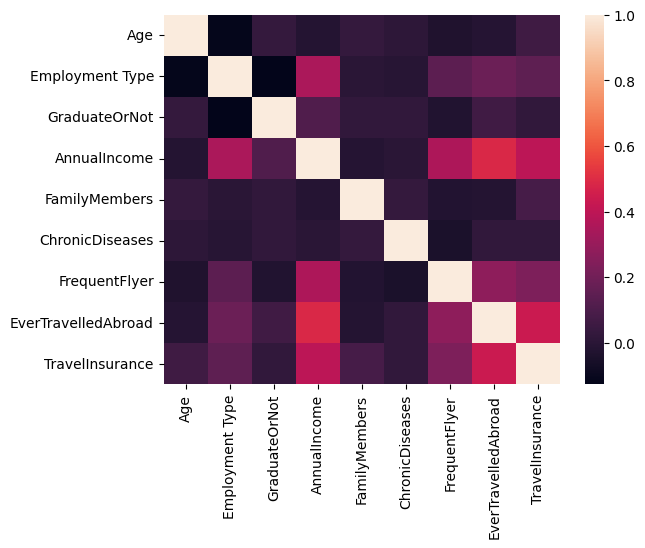

In [16]:
sns.heatmap(df_.corr())
plt.show()

In [17]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    feature_names = df.columns.tolist()
    feature_names.remove("TravelInsurance")

    X = df[feature_names].values
    y = df.TravelInsurance.values
    return X, y

X, y = prepare_X_y(df_)

# Apply machine learning model

## Train-test split

In [18]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 101
TRAIN_SIZE = 0.7

trainX, testX ,trainY, testY = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [19]:
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

### GaussianNB

In [20]:
# Dùng GaussianNB
def build_model(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    scaler = StandardScaler()
    model = GaussianNB()

    pipe = Pipeline(steps=[
        ("scaler", scaler),
        ("model", model)
    ])
    var_smoothing_values = np.logspace(-4, -9, num=100)
    param_grid = {
        'model__var_smoothing': var_smoothing_values
        }
    
    search = GridSearchCV(pipe, param_grid, scoring="recall", n_jobs=2)
    search.fit(X, y)
    print("Best score : ", search.best_score_)
    print("Best parameter : ", search.best_params_)

    return search

def calculate_performance(y_true, y_pred):
    """
    :param y_true: ground truth values
    :param y_pred: predictions
    :return:
    """
    print("precision :", precision_score(y_true, y_pred))
    print("recall :", recall_score(y_true, y_pred))
    print("accuracy :", accuracy_score(y_true, y_pred))
    print("F1 :", f1_score(y_true, y_pred))
    print()

    main_score = recall_score(y_true, y_pred)
    return main_score
 
model = build_model(trainX, trainY)
pred = model.predict(testX)
print()
print("Main Score (Recall) : ", calculate_performance(testY, pred))
print()
print(classification_report(testY, pred))


Best score :  0.5301414141414141
Best parameter :  {'model__var_smoothing': np.float64(0.0001)}

precision : 0.6942675159235668
recall : 0.5141509433962265
accuracy : 0.7470686767169179
F1 : 0.5907859078590786

Main Score (Recall) :  0.5141509433962265

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       385
           1       0.69      0.51      0.59       212

    accuracy                           0.75       597
   macro avg       0.73      0.69      0.70       597
weighted avg       0.74      0.75      0.74       597



### BernoulliNB

In [21]:
# Dùng BernoulliNB
def build_model(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    scaler = MinMaxScaler()
    model = BernoulliNB()

    pipe = Pipeline(steps=[
        ("scaler", scaler),
        ("model", model)
    ])
    alpha_smoothing_values = np.logspace(-4, 1, 50)
    param_grid = {
        "scaler__feature_range": [(-1, 1), (0, 1)],
        'model__alpha': alpha_smoothing_values
        }
    
    search = GridSearchCV(pipe, param_grid, scoring="recall", n_jobs=2)
    search.fit(X, y)
    print("Best score : ", search.best_score_)
    print("Best parameter : ", search.best_params_)

    return search

def calculate_performance(y_true, y_pred):
    """
    :param y_true: ground truth values
    :param y_pred: predictions
    :return:
    """
    print("precision :", precision_score(y_true, y_pred))
    print("recall :", recall_score(y_true, y_pred))
    print("accuracy :", accuracy_score(y_true, y_pred))
    print("F1 :", f1_score(y_true, y_pred))
    print()

    main_score = recall_score(y_true, y_pred)
    return main_score
 
model = build_model(trainX, trainY)
pred = model.predict(testX)
print()
print("Main Score (Recall) : ", calculate_performance(testY, pred))
print()
print(classification_report(testY, pred))


Best score :  0.5362222222222222
Best parameter :  {'model__alpha': np.float64(0.0001), 'scaler__feature_range': (-1, 1)}

precision : 0.7567567567567568
recall : 0.5283018867924528
accuracy : 0.7721943048576214
F1 : 0.6222222222222222

Main Score (Recall) :  0.5283018867924528

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       385
           1       0.76      0.53      0.62       212

    accuracy                           0.77       597
   macro avg       0.77      0.72      0.73       597
weighted avg       0.77      0.77      0.76       597



Chọn recall vì đây là bộ dữ liệu dựa trên thông tin để biết khách hàng nào muốn mua bảo hiểm du lịch 
Recall càng cao thì tỉ lệ bỏ sót những người muốn mua bảo hiểm càng thấp "\
Recall rất quan trọng trong các bài toán dự đoán khách hàng tiềm năng, phát hiện gian lận, rủi ro,...
Tuy nhiên có thể dùng Precision nếu chỉ nhắm đến đối tượng có khả năng mua (chủ yếu dùng cho việc quảng cáo)
                                                    hoặc dùng F1 nếu muốn cân bằng cả Recall và Precision
            
Kết quả Recall của GaussianNB và BernoulliNB đề xấp xỉ 50%, nghĩa là vẫn còn bỏ sót nhiều khách hàng tiềm năng
Mô hình BernoulliNB có kết quả tốt hơn mô hình GaussianNB nhưng không đáng kể (do dữ liệu đa phần là 0/1)